In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries --!

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

import kind
import ex_duffing
import util_data

In [2]:
# --! specify kind arguments --!

parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--file_dir', '../../data/dreamer',
        '--file_name', 'duffing',
        '--data_nsample', '3848',
        '--feature_ndim', '4',
        '--target_ndim', '2',
        '--data_train_size', '0.8',

        '--lookback_nsample', '384',
        '--forecast_nsample', '192',

        '--batch_size', '128',
        '--nepoch', '200',
        '--patience', '20',
        '--checkpoints', '../../models/dreamer',

        '--seg_nsample_stat', '192',
        '--seg_nsample_trans', '192',
        '--fun_stat', '{"sin": 4, "cos": 4}',
        '--fun_trans', '{"data": 12}',
    ]
)

setpoint = [1.0, 0.0]

In [3]:
model = kind.model(args)

dataset = ex_duffing.dataset(
    args.file_dir, args.file_name, args.file_index, args.file_ext,
    args.data_nsample,
    (args.data_train_size, args.data_test_size),
    args.batch_size, (args.lookback_nsample, args.forecast_nsample), setpoint, load_normalized=True)

training = kind.training(model)

In [4]:
model.train()
training.fit(dataset)

>>> training nominal mean >>>
	epoch 1 losses: train=0.269632, valid=0.243390, test=0.243262
	validation loss decreased (inf -> 0.243390), saving model ...
	epoch 2 losses: train=0.229766, valid=0.195145, test=0.193379
	validation loss decreased (0.243390 -> 0.195145), saving model ...
	epoch 3 losses: train=0.118044, valid=0.034354, test=0.033392
	validation loss decreased (0.195145 -> 0.034354), saving model ...
	epoch 4 losses: train=0.012891, valid=0.003694, test=0.003822
	validation loss decreased (0.034354 -> 0.003694), saving model ...
	epoch 5 losses: train=0.002470, valid=0.001779, test=0.001909
	validation loss decreased (0.003694 -> 0.001779), saving model ...
	epoch 6 losses: train=0.001190, valid=0.000886, test=0.000924
	validation loss decreased (0.001779 -> 0.000886), saving model ...
	epoch 7 losses: train=0.000713, valid=0.000568, test=0.000605
	validation loss decreased (0.000886 -> 0.000568), saving model ...
	epoch 8 losses: train=0.000482, valid=0.000401, test=0.00

In [5]:
model.eval()
_, _, data_loader = dataset.load(data_type='nom')

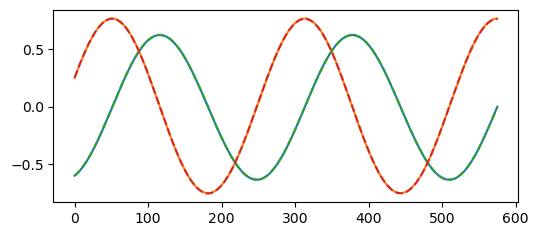

In [6]:
jdata = 2

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        stat = model_output[1]

        plt.figure(figsize=(6,2.5))
        plt.plot(truth[jdata, :, :2])
        plt.plot(stat[0, :, :2], linestyle='dashed')

        plt.show()

        break


In [7]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training nominal uncertainty >>>
	epoch 1 losses: train=0.113359, valid=0.080062, test=0.080480
	validation loss decreased (inf -> 0.080062), saving model ...
	epoch 2 losses: train=0.067492, valid=0.047623, test=0.047935
	validation loss decreased (0.080062 -> 0.047623), saving model ...
	epoch 3 losses: train=0.044472, valid=0.042601, test=0.042868
	validation loss decreased (0.047623 -> 0.042601), saving model ...
	epoch 4 losses: train=0.042709, valid=0.042513, test=0.042834
	validation loss decreased (0.042601 -> 0.042513), saving model ...
	epoch 5 losses: train=0.042698, valid=0.042470, test=0.042829
	validation loss decreased (0.042513 -> 0.042470), saving model ...
	epoch 6 losses: train=0.042652, valid=0.042534, test=0.042765
	early stopping counter: 1 out of 20
	epoch 7 losses: train=0.042649, valid=0.042446, test=0.042740
	validation loss decreased (0.042470 -> 0.042446), saving model ...
	epoch 8 losses: train=0.042620, valid=0.042467, test=0.042733
	early stopping cou

In [8]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

In [9]:
def smoothed_derivative(x, window):
    """
    x: [B, T, 1]
    """
    dx = x[:, 1:, :] - x[:, :-1, :]
    dx = F.pad(dx, (0, 0, 1, 0))

    # Moving average smoothing
    kernel = torch.ones(window, device=x.device) / window
    kernel = kernel.view(1, 1, -1)

    dx = F.conv1d(
        dx.transpose(1, 2),
        kernel,
        padding=window // 2
    ).transpose(1, 2)

    return dx

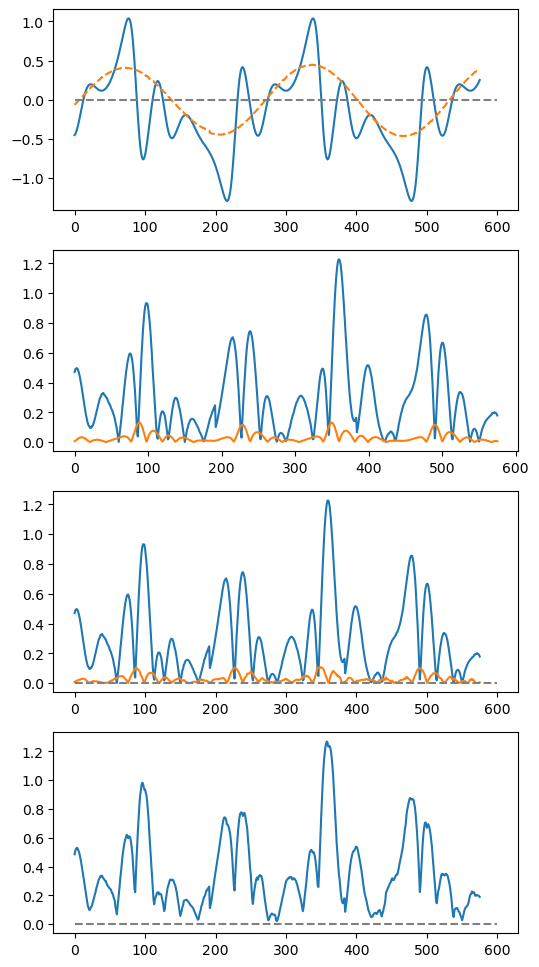

In [10]:
jdata = 1

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        stat = model_output[1]
        zeta_nom = model_output[2]
        signed_error, geometry_error = torch.split(zeta_nom, [2,2], dim=-1)

        a = truth[[jdata], :, 1:2]
        b = stat[[0], :, 1:2]
        slope_a = smoothed_derivative(a, 9)
        slope_b = smoothed_derivative(b, 9)

        value_error = torch.abs(zeta_nom[:, :, 1:2])
        slope_error = torch.abs(slope_a - slope_b)
        beta = 2.0
        geometry_error = torch.abs(geometry_error)
        unsigned_error = torch.abs(signed_error)
        error = unsigned_error + beta * geometry_error

        plt.figure(figsize=(6,12))

        plt.subplot(4,1,1)
        plt.plot(truth[jdata, :, 1:2])
        plt.plot(stat[0, :, 1:2], linestyle='dashed')
        plt.plot([0, 600], [0, 0], linestyle='dashed', color='gray')

        plt.subplot(4,1,2)
        plt.plot(value_error[0, :, :])
        plt.plot(slope_error[0, :, :])

        plt.subplot(4,1,3)
        plt.plot(unsigned_error[0, :, 1:2])
        plt.plot(geometry_error[0, :, 1:2])
        plt.plot([0, 600], [0, 0], linestyle='dashed', color='gray')

        plt.subplot(4,1,4)
        plt.plot(error[0, :, 1])
        plt.plot([0, 600], [0, 0], linestyle='dashed', color='gray')

        plt.show()

        break

#print(tata.shape)

In [11]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training excursion mean >>>
	epoch 1 losses: train=0.357676, valid=0.258422, test=0.258185
	validation loss decreased (inf -> 0.258422), saving model ...
	epoch 2 losses: train=0.214281, valid=0.187740, test=0.187416
	validation loss decreased (0.258422 -> 0.187740), saving model ...
	epoch 3 losses: train=0.183056, valid=0.176232, test=0.175809
	validation loss decreased (0.187740 -> 0.176232), saving model ...
	epoch 4 losses: train=0.167973, valid=0.149331, test=0.149000
	validation loss decreased (0.176232 -> 0.149331), saving model ...
	epoch 5 losses: train=0.133249, valid=0.117263, test=0.116954
	validation loss decreased (0.149331 -> 0.117263), saving model ...
	epoch 6 losses: train=0.094169, valid=0.074924, test=0.074597
	validation loss decreased (0.117263 -> 0.074924), saving model ...
	epoch 7 losses: train=0.074252, valid=0.071720, test=0.071324
	validation loss decreased (0.074924 -> 0.071720), saving model ...
	epoch 8 losses: train=0.071597, valid=0.069710, test=0.

In [12]:
model.eval()
_, _, data_loader = dataset.load(data_type='exc')

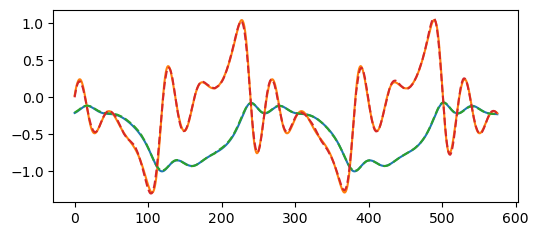

In [13]:
jdata = 0

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        stat = model_output[3]

        plt.figure(figsize=(6,2.5))
        plt.plot(truth[jdata, :, :2])
        plt.plot(stat[0, :, :2], linestyle='dashed')

        plt.show()

        break

In [14]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training excursion uncertainty >>>
	epoch 1 losses: train=0.150487, valid=0.108150, test=0.108649
	validation loss decreased (inf -> 0.108150), saving model ...
	epoch 2 losses: train=0.086248, valid=0.064703, test=0.064454
	validation loss decreased (0.108150 -> 0.064703), saving model ...
	epoch 3 losses: train=0.062061, valid=0.060441, test=0.060302
	validation loss decreased (0.064703 -> 0.060441), saving model ...
	epoch 4 losses: train=0.060678, valid=0.060045, test=0.059688
	validation loss decreased (0.060441 -> 0.060045), saving model ...
	epoch 5 losses: train=0.060031, valid=0.059603, test=0.059330
	validation loss decreased (0.060045 -> 0.059603), saving model ...
	epoch 6 losses: train=0.059797, valid=0.059614, test=0.059346
	early stopping counter: 1 out of 20
	epoch 7 losses: train=0.059824, valid=0.059522, test=0.059222
	validation loss decreased (0.059603 -> 0.059522), saving model ...
	epoch 8 losses: train=0.059573, valid=0.059172, test=0.058912
	validation loss 

In [15]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

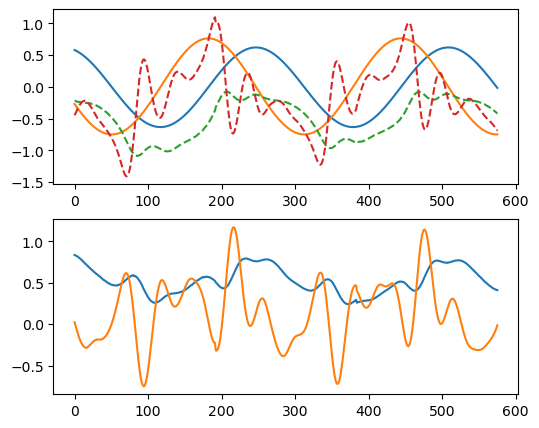

In [16]:
jdata = 2

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        exc = model_output[3]
        exc_u = model_output[4]

        plt.figure(figsize=(6,5))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :2])
        plt.plot(exc[0, :, :2], linestyle='dashed')

        plt.subplot(2,1,2)
        plt.plot(exc_u[0, :, :2])

        plt.show()

        break

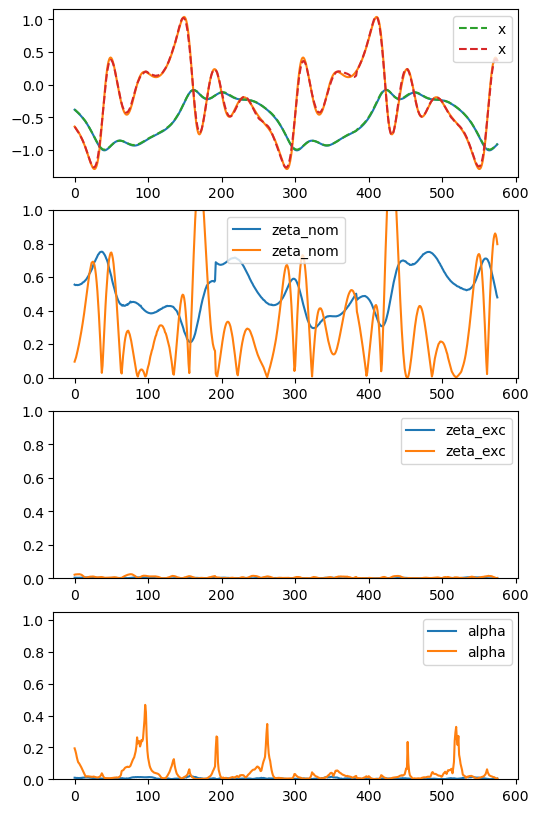

In [28]:
jdata = 11

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        pre = model_output[0]
        u_nom = torch.abs(model_output[2])
        u_exc = torch.abs(model_output[4])
        alpha = model_output[9]

        plt.figure(figsize=(6,10))

        plt.subplot(4,1,1)
        plt.plot(truth[jdata, :, :2])
        plt.plot(pre[0, :, :2], linestyle='dashed', label='x')
        plt.legend()

        plt.subplot(4,1,2)
        plt.plot(u_nom[0, :, :2], label='zeta_nom')
        plt.ylim((0,1))
        plt.legend()

        plt.subplot(4,1,3)
        plt.plot(u_exc[0, :, :2], label='zeta_exc')
        plt.ylim((0,1))
        plt.legend()

        plt.subplot(4,1,4)
        plt.plot(alpha[0, :, :2], label='alpha')
        plt.ylim((0.0, 1.05))
        plt.legend()

        plt.show()

        break